# Initial Data Exploration

## What is the objective of this notebook?

The objective of this notebook is to validate and explore the cleaned dataset generated by the Market Data Pipeline. It checks the structure of the data, analyses normalized prices, computes returns, studies volatility and explores correlations between the selected assets.

This analysis focuses on:

- checking the structure and quality of the data;
- comparing normalized asset price evolution;
- computing daily returns;
- analysing volatility differences across assets;
- studying correlations between asset classes.

## Which assets are included and why?

The asset universe includes AAPL, MSFT and NVDA as technology/growth stocks; JPM as a financial sector stock; XOM as an energy stock; SPY as broad US equity market exposure; TLT as long-term US Treasury bond exposure; and GLD as gold exposure. This selection allows the project to analyse different sources of risk and diversification.

## What data field is used for analysis? Why?

The main data field used for analysis is Adjusted Close, because it provides a price series adjusted for corporate actions such as dividends and stock splits.

We use Adjusted Close because it adjusts historical prices for dividends and stock splits. This gives a more consistent price series for calculating returns and avoids artificial jumps caused by corporate actions.

## What period of data is analysed?

The dataset starts on 2015-01-01 and ends at the most recent date available from Yahoo Finance when the pipeline is executed.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/processed/adjusted_close_prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-02,24.192608,114.080002,46.066795,39.681755,0.482423,169.687820,92.659340,57.145554
2015-01-05,23.511061,115.800003,44.636646,39.316833,0.474275,166.623322,94.114830,55.581932
2015-01-06,23.513271,117.120003,43.479256,38.739777,0.459896,165.053909,95.810509,55.286461
2015-01-07,23.842979,116.430000,43.545612,39.231972,0.458697,167.110718,95.621277,55.846642
2015-01-08,24.759079,115.940002,44.518688,40.386112,0.475952,170.076065,94.355003,56.776207


In [2]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2905 entries, 2015-01-02 to 2026-07-23
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2905 non-null   float64
 1   GLD     2905 non-null   float64
 2   JPM     2905 non-null   float64
 3   MSFT    2905 non-null   float64
 4   NVDA    2905 non-null   float64
 5   SPY     2905 non-null   float64
 6   TLT     2905 non-null   float64
 7   XOM     2905 non-null   float64
dtypes: float64(8)
memory usage: 204.3 KB


In [3]:
prices.describe()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
count,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000
mean,114.365091,178.123828,127.342804,214.970760,40.564906,353.825168,99.323812,71.688749
std,81.343299,80.842351,75.629586,145.932256,59.833974,157.910991,15.639839,29.710571
min,20.565866,100.500000,40.088203,34.284481,0.458697,154.161621,73.702675,23.823559
25%,37.426491,121.309998,76.714874,76.429825,3.879959,224.089630,87.588104,52.104061
50%,113.001923,162.250000,103.959076,203.091949,12.526487,316.888306,94.684486,56.771629
75%,174.331360,183.970001,145.341904,326.864594,43.958988,434.675781,106.182167,98.192734
max,333.739990,495.899994,349.899994,538.658569,235.465576,757.618225,142.699554,170.313995


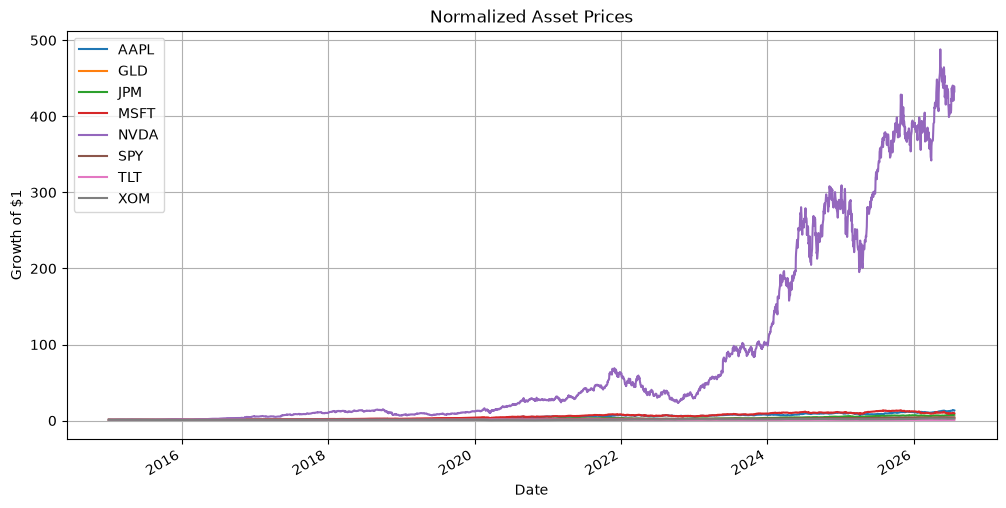

In [4]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))
plt.title("Normalized Asset Prices")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## How have prices evolved after normalization?

After normalization, all assets start at the same value, usually 1. This allows us to compare their relative growth. Assets with higher final normalized values have generated stronger cumulative growth over the analysed period.

## Which assets had the strongest growth?

NVDA shows the strongest normalized growth over the period, meaning that one dollar invested in NVDA at the beginning of the period would have grown more than one dollar invested in the other selected assets.

In [5]:
returns = pd.read_csv(
    "../data/processed/simple_returns.csv",
    index_col=0,
    parse_dates=True,
)

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016891,-0.018060,0.015708,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014677,-0.030318,-0.009419,0.018017,-0.005316
2015-01-07,0.014022,-0.005891,0.001526,0.012705,-0.002606,0.012461,-0.001975,0.010132
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037617,0.017745,-0.013243,0.016645
2015-01-09,0.001073,0.011385,-0.017387,-0.008405,0.004028,-0.008013,0.010952,-0.001410


In [6]:
returns.describe()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
count,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000
mean,0.001055,0.000458,0.000843,0.000927,0.002550,0.000568,0.000006,0.000498
std,0.018098,0.010133,0.017010,0.017161,0.030384,0.011100,0.009334,0.017337
min,-0.128647,-0.102742,-0.149649,-0.147390,-0.187559,-0.109424,-0.066683,-0.122248
25%,-0.007311,-0.004767,-0.007030,-0.007051,-0.012654,-0.003705,-0.005613,-0.008186
50%,0.000970,0.000556,0.000721,0.000868,0.002583,0.000645,0.000324,0.000393
75%,0.009942,0.005569,0.008955,0.009499,0.017600,0.005930,0.005466,0.009257
max,0.153289,0.063587,0.180125,0.142169,0.298067,0.105020,0.075196,0.126868


In [7]:
daily_volatility = returns.std().sort_values(ascending=False)
daily_volatility

NVDA    0.030384
AAPL    0.018098
XOM     0.017337
MSFT    0.017161
JPM     0.017010
SPY     0.011100
GLD     0.010133
TLT     0.009334
dtype: float64

## Which assets appear more volatile?

NVDA appears as the most volatile asset, according to the standard deviation of daily returns. This is consistent with its profile as a high-growth technology stock.

## Which assets appear less volatile?

TLT is the least volatile asset in this sample, although long-duration bonds can still be risky, especially when interest rates change.

In [8]:
daily_volatility * (252 ** 0.5)

NVDA    0.482332
AAPL    0.287301
XOM     0.275223
MSFT    0.272416
JPM     0.270027
SPY     0.176204
GLD     0.160854
TLT     0.148169
dtype: float64

In [9]:
returns.mean()

AAPL    0.001055
GLD     0.000458
JPM     0.000843
MSFT    0.000927
NVDA    0.002550
SPY     0.000568
TLT     0.000006
XOM     0.000498
dtype: float64

In [10]:
returns.mean() * 252

AAPL    0.265841
GLD     0.115454
JPM     0.212380
MSFT    0.233564
NVDA    0.642515
SPY     0.143175
TLT     0.001595
XOM     0.125542
dtype: float64

In [11]:
correlation_matrix = returns.corr()
correlation_matrix

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
AAPL,1.000000,0.029219,0.414981,0.638117,0.515018,0.735790,-0.107678,0.286405
GLD,0.029219,1.000000,-0.072156,0.028472,0.038686,0.068910,0.257766,0.035621
JPM,0.414981,-0.072156,1.000000,0.419692,0.335553,0.710716,-0.318207,0.511229
MSFT,0.638117,0.028472,0.419692,1.000000,0.584956,0.759868,-0.116289,0.247151
NVDA,0.515018,0.038686,0.335553,0.584956,1.000000,0.646268,-0.073243,0.181941
SPY,0.735790,0.068910,0.710716,0.759868,0.646268,1.000000,-0.173035,0.500979
TLT,-0.107678,0.257766,-0.318207,-0.116289,-0.073243,-0.173035,1.000000,-0.240864
XOM,0.286405,0.035621,0.511229,0.247151,0.181941,0.500979,-0.240864,1.000000


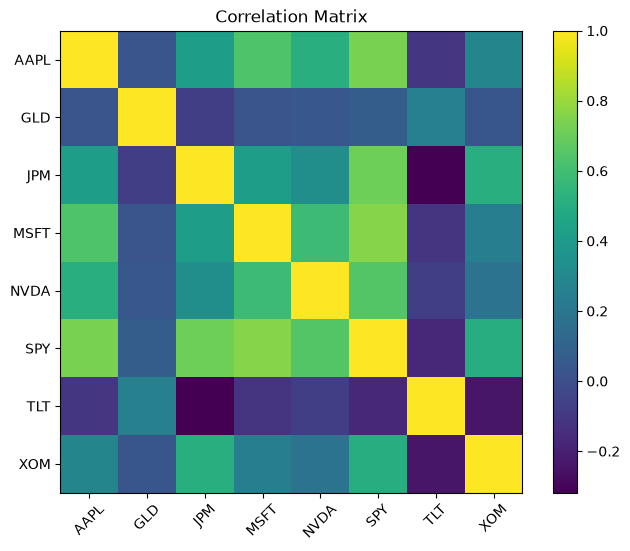

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")
plt.show()

## Which assets are highly correlated?

These assets are highly correlated because they are all exposed to US equity market risk. SPY is a broad market ETF, and AAPL/MSFT have large weights in the US equity market.

## Which assets are less correlated?

Pairs involving TLT and GLD tend to show lower or negative correlations with equities. For example, JPM-TLT and XOM-TLT show negative correlation, which suggests potential diversification benefits.

## What does this imply for diversification?

This implies that combining assets with low or negative correlations can reduce portfolio risk. If all assets moved together, diversification would be limited. Assets such as TLT and GLD may help diversify equity exposure because they are driven by different risk factors.

## What are the limitations of this initial analysis?

This initial analysis is descriptive and historical. It does not predict future returns and does not yet include formal risk metrics such as maximum drawdown, Sharpe ratio, VaR or CVaR. It also uses a small asset universe and only daily historical market data from Yahoo Finance.

## What will be done in the next phase?

The next phase will compute formal risk and performance metrics, including annualized volatility, maximum drawdown, Sharpe ratio, Sortino ratio, Value at Risk and Conditional Value at Risk.